# Regresión lineal simple y múltiple con Auto MPG

En este notebook se construirá un modelo para estimar el rendimiento de combustible de un automóvil, medido en millas por galón (`mpg`). https://archive.ics.uci.edu/dataset/9/auto+mpg

Primero se estudiará una **regresión lineal simple**, utilizando únicamente el peso del automóvil (`weight`). Después se ampliará el análisis a una **regresión lineal múltiple**, incorporando también el desplazamiento del motor (`displacement`).

## Objetivos

- Explorar y comprender la base de datos.
- Identificar la relación entre las variables.
- Separar los datos en entrenamiento y prueba.
- Entrenar un modelo de regresión lineal.
- Comparar valores reales y predichos.
- Evaluar el modelo mediante métricas de error.
- Analizar los residuos.
- Extender el modelo a dos variables predictoras.


In [1]:
from ucimlrepo import fetch_ucirepo

# fetch dataset
auto_mpg = fetch_ucirepo(id=9)

# data (as pandas dataframes)
data_X = auto_mpg.data.features
data_y = auto_mpg.data.targets

# metadata
print(auto_mpg.metadata)

# variable information
print(auto_mpg.variables)


{'uci_id': 9, 'name': 'Auto MPG', 'repository_url': 'https://archive.ics.uci.edu/dataset/9/auto+mpg', 'data_url': 'https://archive.ics.uci.edu/static/public/9/data.csv', 'abstract': 'Revised from CMU StatLib library, data concerns city-cycle fuel consumption', 'area': 'Other', 'tasks': ['Regression'], 'characteristics': ['Multivariate'], 'num_instances': 398, 'num_features': 7, 'feature_types': ['Real', 'Categorical', 'Integer'], 'demographics': [], 'target_col': ['mpg'], 'index_col': ['car_name'], 'has_missing_values': 'yes', 'missing_values_symbol': 'NaN', 'year_of_dataset_creation': 1993, 'last_updated': 'Thu Aug 10 2023', 'dataset_doi': '10.24432/C5859H', 'creators': ['R. Quinlan'], 'intro_paper': None, 'additional_info': {'summary': 'This dataset is a slightly modified version of the dataset provided in the StatLib library.  In line with the use by Ross Quinlan (1993) in predicting the attribute "mpg", 8 of the original instances were removed because they had unknown values for th

## 1. Obtención de la base de datos

La función `fetch_ucirepo` permite obtener la base Auto MPG desde el repositorio de la UCI.

La información se recibe separada en:

- **Características:** variables que describen a cada automóvil.
- **Objetivo:** variable que se desea predecir, en este caso `mpg`.
- **Metadatos:** descripción general de la base.
- **Variables:** nombre, tipo y función de cada columna.


In [3]:
import pandas as pd
data= pd.concat([data_X,data_y],axis=1)


## 2. Construcción del DataFrame

Las características y la variable objetivo se unen horizontalmente para trabajar con una sola tabla denominada `data`.

De esta manera, cada fila conserva la información completa de un automóvil.


In [4]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 398 entries, 0 to 397
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   displacement  398 non-null    float64
 1   cylinders     398 non-null    int64  
 2   horsepower    392 non-null    float64
 3   weight        398 non-null    int64  
 4   acceleration  398 non-null    float64
 5   model_year    398 non-null    int64  
 6   origin        398 non-null    int64  
 7   mpg           398 non-null    float64
dtypes: float64(4), int64(4)
memory usage: 25.0 KB


In [5]:
data.isnull().sum()

displacement    0
cylinders       0
horsepower      6
weight          0
acceleration    0
model_year      0
origin          0
mpg             0
dtype: int64

In [6]:
data.describe()

,displacement,cylinders,horsepower,weight,acceleration,model_year,origin,mpg
count,398.000000,398.000000,392.000000,398.000000,398.000000,398.000000,398.000000,398.000000
mean,193.425879,5.454774,104.469388,2970.424623,15.568090,76.010050,1.572864,23.514573
std,104.269838,1.701004,38.491160,846.841774,2.757689,3.697627,0.802055,7.815984
min,68.000000,3.000000,46.000000,1613.000000,8.000000,70.000000,1.000000,9.000000
25%,104.250000,4.000000,75.000000,2223.750000,13.825000,73.000000,1.000000,17.500000
50%,148.500000,4.000000,93.500000,2803.500000,15.500000,76.000000,1.000000,23.000000
75%,262.000000,8.000000,126.000000,3608.000000,17.175000,79.000000,2.000000,29.000000
max,455.000000,8.000000,230.000000,5140.000000,24.800000,82.000000,3.000000,46.600000


In [7]:
data.corr()

,displacement,cylinders,horsepower,weight,acceleration,model_year,origin,mpg
displacement,1.000000,0.950721,0.897257,0.932824,-0.543684,-0.370164,-0.609409,-0.804203
cylinders,0.950721,1.000000,0.842983,0.896017,-0.505419,-0.348746,-0.562543,-0.775396
horsepower,0.897257,0.842983,1.000000,0.864538,-0.689196,-0.416361,-0.455171,-0.778427
weight,0.932824,0.896017,0.864538,1.000000,-0.417457,-0.306564,-0.581024,-0.831741
acceleration,-0.543684,-0.505419,-0.689196,-0.417457,1.000000,0.288137,0.205873,0.420289
model_year,-0.370164,-0.348746,-0.416361,-0.306564,0.288137,1.000000,0.180662,0.579267
origin,-0.609409,-0.562543,-0.455171,-0.581024,0.205873,0.180662,1.000000,0.563450
mpg,-0.804203,-0.775396,-0.778427,-0.831741,0.420289,0.579267,0.563450,1.000000


In [8]:
data.duplicated().sum()

np.int64(0)

## 3. Análisis exploratorio de datos

Antes de entrenar un modelo es necesario conocer la estructura y la calidad de la información.

En esta etapa se revisan:

- dimensiones y tipos de datos;
- valores faltantes;
- estadísticas descriptivas;
- relaciones lineales entre variables;
- registros duplicados.

La correlación de Pearson mide la intensidad y dirección de una relación lineal:

$$
r_{xy}=
\frac{\operatorname{cov}(X,Y)}
{\sigma_X\sigma_Y}
$$

Sus valores se encuentran entre $-1$ y $1$:

- cercano a $1$: relación positiva;
- cercano a $-1$: relación negativa;
- cercano a $0$: poca relación lineal.


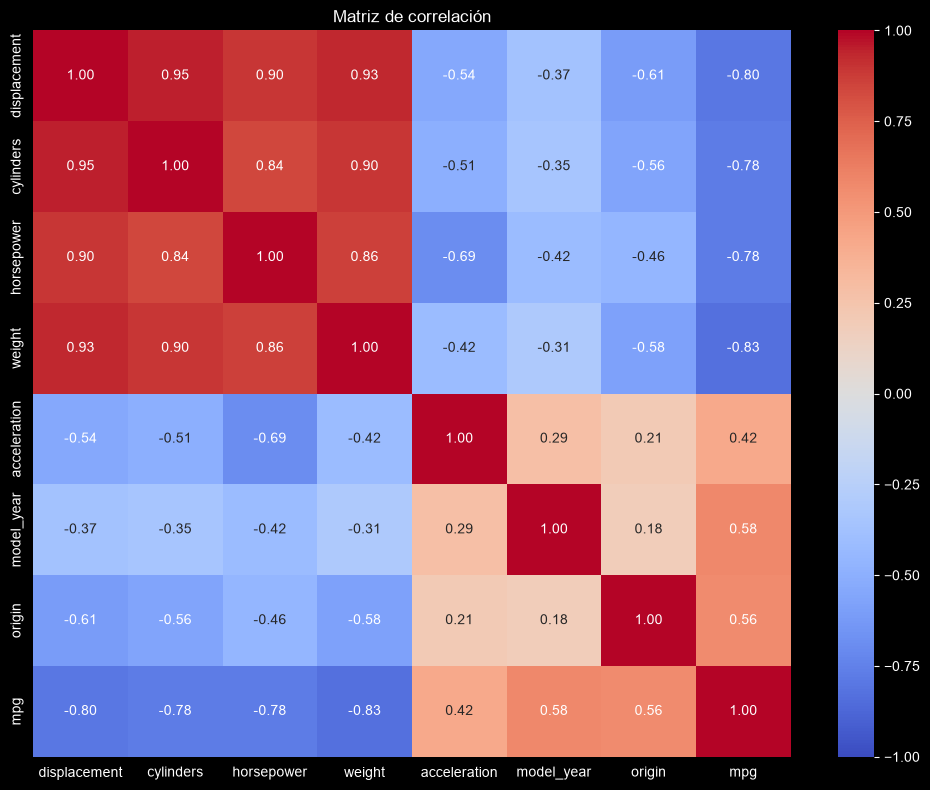

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

matriz_correlacion = data.corr(numeric_only=True)

plt.figure(figsize=(10, 8))

sns.heatmap(
    matriz_correlacion,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    vmin=-1,
    vmax=1
)

plt.title("Matriz de correlación")
plt.tight_layout()
plt.show()

## 4. Selección de variables para la regresión simple

Para el primer modelo se seleccionan únicamente:

- `weight`: peso del automóvil, variable predictora;
- `mpg`: rendimiento de combustible, variable objetivo.

El nuevo DataFrame permite concentrar el análisis en la relación que se desea modelar.


In [10]:
data_regresion= data[["weight","mpg"]]
print(data_regresion.head())
print(data_regresion.info())
print(data_regresion.describe())

   weight   mpg
0    3504  18.0
1    3693  15.0
2    3436  18.0
3    3433  16.0
4    3449  17.0
<class 'pandas.DataFrame'>
RangeIndex: 398 entries, 0 to 397
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   weight  398 non-null    int64  
 1   mpg     398 non-null    float64
dtypes: float64(1), int64(1)
memory usage: 6.3 KB
None
            weight         mpg
count   398.000000  398.000000
mean   2970.424623   23.514573
std     846.841774    7.815984
min    1613.000000    9.000000
25%    2223.750000   17.500000
50%    2803.500000   23.000000
75%    3608.000000   29.000000
max    5140.000000   46.600000


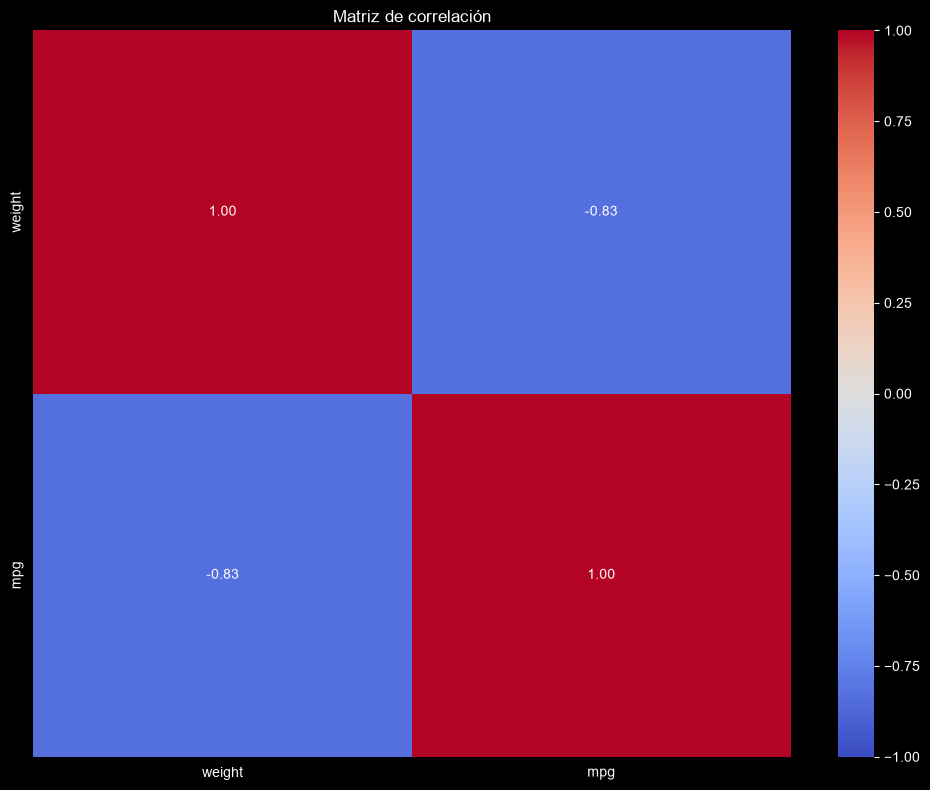

In [11]:

matriz_correlacion = data_regresion.corr(numeric_only=True)

plt.figure(figsize=(10, 8))

sns.heatmap(
    matriz_correlacion,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    vmin=-1,
    vmax=1
)

plt.title("Matriz de correlación")
plt.tight_layout()
plt.show()

## 5. Distribución de las variables

Los histogramas permiten observar cómo se distribuyen los valores de `weight` y `mpg`.

La curva de densidad facilita la identificación de concentraciones, asimetrías y zonas con pocas observaciones.


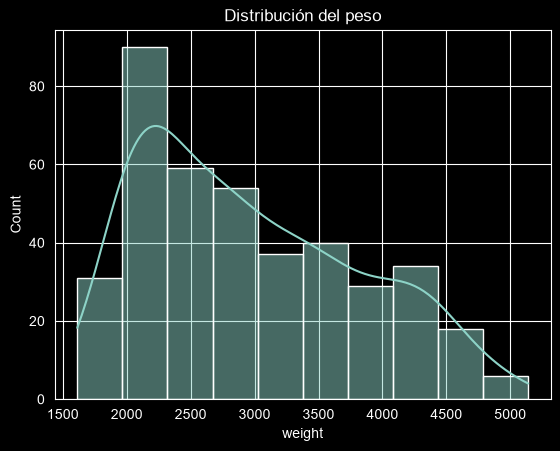

In [12]:

sns.histplot(data=data_regresion, x="weight", kde=True)
plt.title("Distribución del peso")
plt.show()

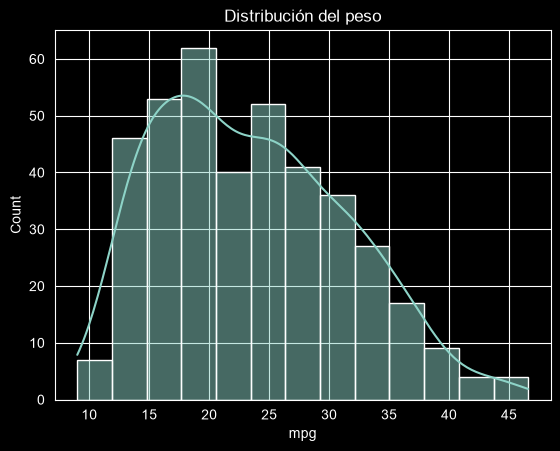

In [13]:
sns.histplot(data=data_regresion, x="mpg", kde=True)
plt.title("Distribución del peso")
plt.show()

In [14]:
data_regresion

,weight,mpg
0,3504,18.0
1,3693,15.0
2,3436,18.0
3,3433,16.0
4,3449,17.0
...,...,...
393,2790,27.0
394,2130,44.0
395,2295,32.0
396,2625,28.0


## 6. Identificación visual de valores atípicos

Los diagramas de caja permiten detectar observaciones alejadas del comportamiento general.

Un valor atípico no debe eliminarse automáticamente. Primero debe comprobarse si corresponde a un error o a un automóvil con características poco comunes.


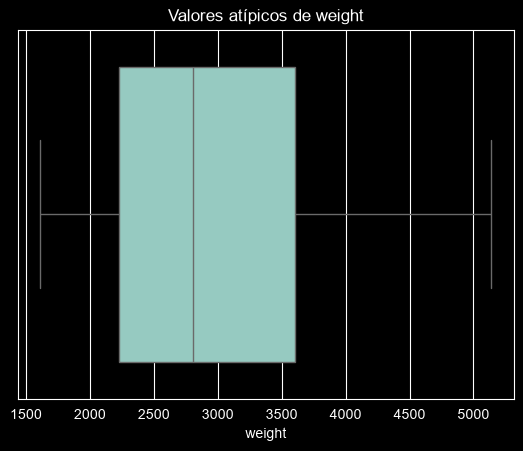

In [15]:
sns.boxplot(data=data_regresion, x="weight")
plt.title("Valores atípicos de weight")
plt.show()

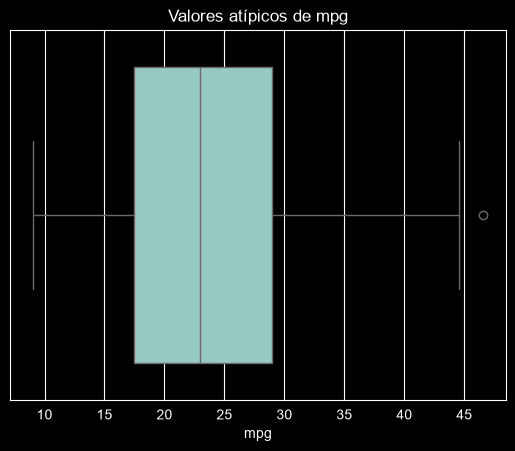

In [16]:
sns.boxplot(data=data_regresion, x="mpg")
plt.title("Valores atípicos de mpg")
plt.show()

## 7. Relación entre peso y rendimiento

La gráfica de dispersión representa cada automóvil mediante un punto:

$$
(\text{weight},\text{mpg})
$$

La nube de puntos permite comprobar si existe una tendencia lineal. La línea agregada posteriormente resume visualmente esa tendencia.


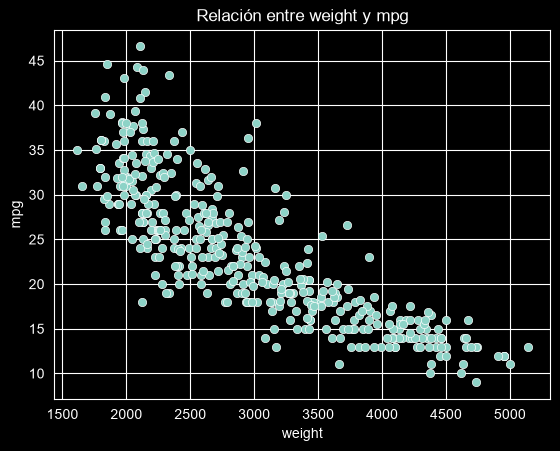

In [17]:
sns.scatterplot(
    data=data_regresion,
    x="weight",
    y="mpg"
)

plt.title("Relación entre weight y mpg")
plt.show()

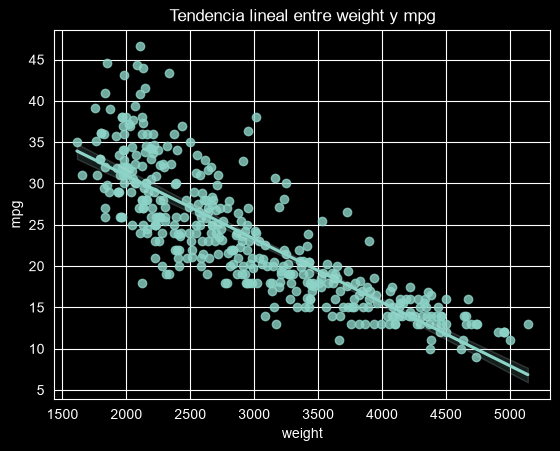

In [18]:
sns.regplot(
    data=data_regresion,
    x="weight",
    y="mpg"
)

plt.title("Tendencia lineal entre weight y mpg")
plt.show()

## 8. Correlación entre `weight` y `mpg`

En esta parte se obtiene un único coeficiente de correlación para las dos variables seleccionadas.

Un valor negativo indica que, en general, el rendimiento disminuye conforme aumenta el peso del automóvil.


In [19]:
data_regresion["weight"].corr(data_regresion["mpg"])

np.float64(-0.8317409332443352)

## 9. Definición de la entrada y la salida

El modelo necesita distinguir entre:

- $X$: variable utilizada para realizar la predicción;
- $y$: valor que se desea predecir.

En Scikit-learn, la entrada debe conservar una estructura bidimensional, incluso cuando contiene una sola característica.


In [20]:

X_data=data_regresion[["weight"]]
Y_data=data_regresion["mpg"]
print(X_data.shape)
print(Y_data.shape)

(398, 1)
(398,)


## 10. División en entrenamiento y prueba

Los datos se separan en dos conjuntos:

- **80 % para entrenamiento:** se utiliza para aprender la relación entre `weight` y `mpg`.
- **20 % para prueba:** se utiliza para evaluar el modelo con observaciones que no participaron en el entrenamiento.

El parámetro `random_state` permite reproducir la misma división en ejecuciones posteriores.


In [21]:
from sklearn.model_selection import train_test_split

X_train, X_test, Y_train, Y_test = train_test_split(X_data,Y_data,test_size=0.20,random_state=42)

print("X entrenamiento:", X_train.shape)
print("X prueba:", X_test.shape)
print("Y entrenamiento:", Y_train.shape)
print("Y prueba:", Y_test.shape)

X entrenamiento: (318, 1)
X prueba: (80, 1)
Y entrenamiento: (318,)
Y prueba: (80,)


## 11. Entrenamiento de la regresión lineal

`LinearRegression` crea el modelo y `fit` aprende la recta que mejor representa los datos de entrenamiento.

La regresión lineal simple tiene la forma:

$$
\hat{y}=mx+b
$$

donde:

- $\hat{y}$ es el valor estimado;
- $m$ es la pendiente;
- $x$ es el peso;
- $b$ es la intersección.

El modelo selecciona $m$ y $b$ minimizando la suma de errores cuadrados:

$$
\min_{m,b}
\sum_{i=1}^{n}
\left(y_i-\hat{y}_i\right)^2
$$


In [22]:
from sklearn.linear_model import LinearRegression

# Crear el modelo
modelo = LinearRegression()

# Entrenar el modelo
modelo.fit(X_train, Y_train)



,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](1,)",[-0.01]
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](1,)",['weight']
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,46.78
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,1
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(1)


## 12. Ecuación aprendida por el modelo

Después del entrenamiento:

- `coef_` contiene la pendiente de la recta;
- `intercept_` contiene la intersección.

Con estos valores se obtiene la ecuación específica que estima `mpg` a partir de `weight`.

Una pendiente negativa indica que el rendimiento estimado disminuye cuando aumenta el peso.


In [23]:

# Obtener la pendiente y la intersección
pendiente = modelo.coef_[0]
interseccion = modelo.intercept_

print(f"Pendiente: {pendiente:.6f}")
print(f"Intersección: {interseccion:.6f}")

# Mostrar la ecuación de la recta de regresión
print(
    f"mpg_estimado = "
    f"{pendiente:.6f} × weight "
    f"+ {interseccion:.6f}"
)

Pendiente: -0.007805
Intersección: 46.782063
mpg_estimado = -0.007805 × weight + 46.782063


## 13. Predicción sobre el conjunto de prueba

El método `predict` utiliza la ecuación aprendida para estimar el valor de `mpg` de cada automóvil del conjunto de prueba.

Estas predicciones se compararán con los valores reales.


In [26]:
Y_pred = modelo.predict(X_test)

## 14. Comparación entre valores reales y predichos

La tabla permite observar, para cada automóvil:

- su peso;
- el rendimiento real;
- el rendimiento predicho;
- el residuo.

El residuo se calcula como:

$$
e_i=y_i-\hat{y}_i
$$

Un residuo cercano a cero indica que la predicción se encuentra cerca del valor real.


In [27]:
results = pd.DataFrame({"weight": X_test["weight"].reset_index(drop=True),"mpg_real": Y_test.reset_index(drop=True),"mpg_predicho": Y_pred})
results["residuo"] = (results["mpg_real"] - results["mpg_predicho"])
results.head(10)

,weight,mpg_real,mpg_predicho,residuo
0,1795,33.0,32.771653,0.228347
1,2625,28.0,26.293302,1.706698
2,2634,19.0,26.223055,-7.223055
3,3940,13.0,16.029409,-3.029409
4,4237,14.0,13.711252,0.288748
5,2100,27.0,30.391054,-3.391054
6,2865,24.0,24.420044,-0.420044
7,4735,13.0,9.824241,3.175759
8,4060,17.0,15.092779,1.907221
9,2875,21.0,24.341992,-3.341992


## 15. Visualización de la recta de regresión

La gráfica reúne los datos de entrenamiento, los datos de prueba y la recta aprendida.

La distancia vertical entre un punto y la recta representa su residuo.


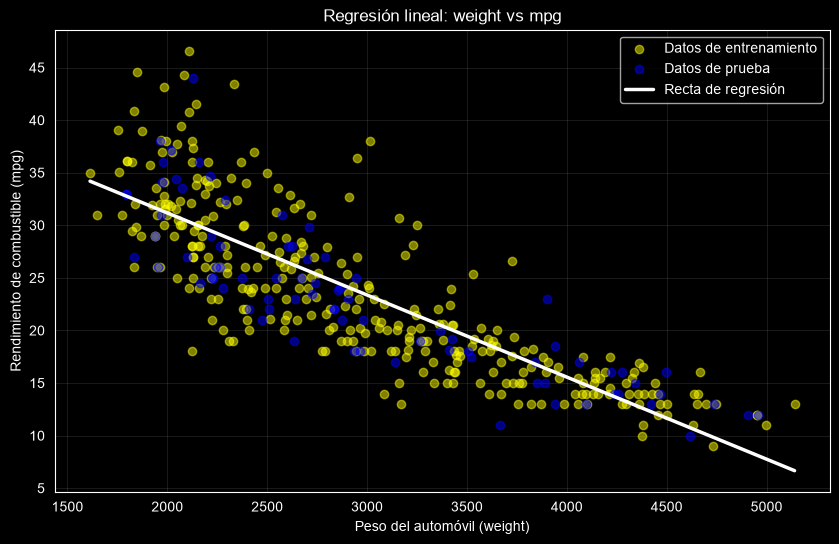

In [28]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

weight_linea = np.linspace(X_data["weight"].min(), X_data["weight"].max(), 200)
weight_linea_df = pd.DataFrame({"weight": weight_linea})
mpg_linea = modelo.predict(weight_linea_df)

plt.figure(figsize=(10, 6))
plt.scatter(X_train["weight"], Y_train, color="yellow", alpha=0.5, label="Datos de entrenamiento")
plt.scatter(X_test["weight"], Y_test, color="blue", alpha=0.5, label="Datos de prueba")
plt.plot(weight_linea, mpg_linea, color="white", linewidth=2.5, label="Recta de regresión")
plt.xlabel("Peso del automóvil (weight)")
plt.ylabel("Rendimiento de combustible (mpg)")
plt.title("Regresión lineal: weight vs mpg")
plt.legend()
plt.grid(alpha=0.1)
plt.show()

## 16. Métricas de evaluación

Las métricas resumen el desempeño del modelo desde diferentes perspectivas.

### Error absoluto medio

$$
MAE=
\frac{1}{n}
\sum_{i=1}^{n}
\left|y_i-\hat{y}_i\right|
$$

Indica el error promedio en las mismas unidades de `mpg`.

### Error cuadrático medio

$$
MSE=
\frac{1}{n}
\sum_{i=1}^{n}
\left(y_i-\hat{y}_i\right)^2
$$

Penaliza con mayor intensidad los errores grandes.

### Raíz del error cuadrático medio

$$
RMSE=
\sqrt{
\frac{1}{n}
\sum_{i=1}^{n}
\left(y_i-\hat{y}_i\right)^2
}
$$

Se expresa nuevamente en unidades de `mpg`.

### Coeficiente de determinación

$$
R^2=
1-
\frac{
\sum_{i=1}^{n}
\left(y_i-\hat{y}_i\right)^2
}{
\sum_{i=1}^{n}
\left(y_i-\bar{y}\right)^2
}
$$

$R^2$ indica qué proporción de la variación de `mpg` puede explicar el modelo. No representa un porcentaje de aciertos.


In [29]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score,
)
mae = mean_absolute_error(Y_test,y_pred)

mse = mean_squared_error(Y_test,y_pred)

rmse = np.sqrt(mse)

r2 = r2_score(Y_test,y_pred,)

print(f"MAE:  {mae:.4f} mpg")
print(f"MSE:  {mse:.4f}")
print(f"RMSE: {rmse:.4f} mpg")
print(f"R²:   {r2:.4f}")

MAE:  3.1178 mpg
MSE:  14.8949
RMSE: 3.8594 mpg
R²:   0.7230


## 17. Predicción de un automóvil nuevo

Una vez entrenado, el modelo puede recibir un peso nuevo y producir una estimación de su rendimiento.

La predicción debe interpretarse dentro del contexto y del rango de los datos utilizados para entrenar el modelo.


In [30]:
# Ingresando un dato nuevo
new_car = pd.DataFrame({"weight": [3000,]})
predicted_mpg = modelo.predict(new_car)[0]
print("Peso: 3000 lb")
print(f"Rendimiento estimado: "f"{predicted_mpg:.2f} mpg")

Peso: 3000 lb
Rendimiento estimado: 23.37 mpg


## 18. Análisis de residuos

La gráfica de residuos permite revisar cómo se distribuyen los errores respecto a las predicciones.

En un modelo lineal adecuado se espera:

- puntos distribuidos alrededor de cero;
- ausencia de curvas o patrones definidos;
- dispersión aproximadamente constante;
- pocos residuos excesivamente grandes.

Un patrón evidente puede indicar que una recta no representa por completo la relación entre las variables.


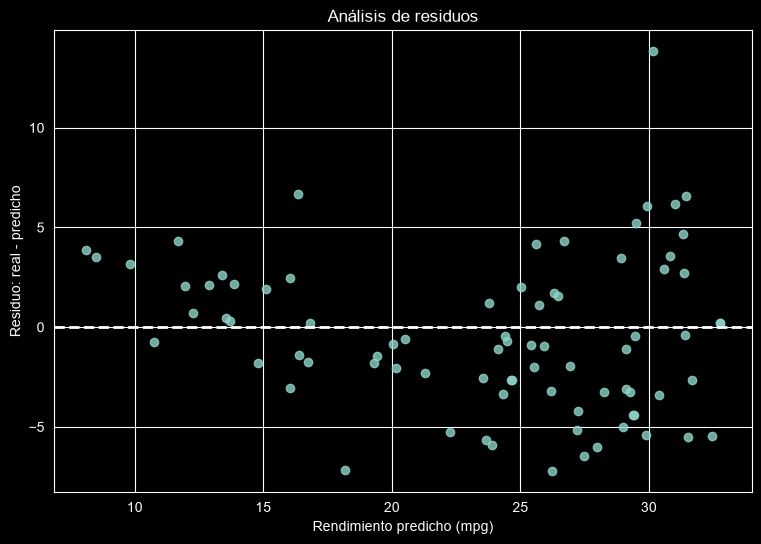

In [31]:
# Analizando los residuos
residuals = (Y_test- Y_pred)

plt.figure(figsize=(9, 6))

plt.scatter(y_pred,residuals,alpha=0.8)

plt.axhline(y=0,linestyle="--",linewidth=2,)

plt.xlabel("Rendimiento predicho (mpg)")
plt.ylabel("Residuo: real - predicho")
plt.title("Análisis de residuos")
plt.grid(True)
plt.show()

## 19. Regresión lineal múltiple

La regresión lineal múltiple utiliza dos o más variables predictoras.

En este caso se emplean `weight` y `displacement`:

$$
\widehat{mpg}
=
b+
m_1(\text{weight})+
m_2(\text{displacement})
$$

Cada coeficiente representa el cambio estimado en `mpg` asociado con una variable, manteniendo la otra constante.

El proceso de división, entrenamiento y predicción es el mismo; cambia únicamente el número de características de entrada.


In [32]:
#Regresión lineal multiple variable
X_data = data[["weight", "displacement"]].copy()
Y_data = data["mpg"].copy()
X_train, X_test, Y_train, Y_test = train_test_split(X_data, Y_data, test_size=0.20, random_state=42)

modelo_multiple = LinearRegression()
modelo_multiple.fit(X_train, Y_train)

Y_pred = modelo_multiple.predict(X_test)
print("Coeficientes:", modelo_multiple.coef_)
print("Intersección:", modelo_multiple.intercept_)
print(X_data.columns)

Coeficientes: [-0.00570729 -0.01842411]
Intersección: 44.08885823461313
Index(['weight', 'displacement'], dtype='str')


## 20. Plano de regresión

Con dos variables predictoras, el modelo ya no se representa mediante una recta en dos dimensiones, sino mediante un plano en tres dimensiones.

Cada punto corresponde a un automóvil con coordenadas:

$$
(\text{weight},\text{displacement},\text{mpg})
$$

El plano representa las estimaciones producidas por el modelo múltiple.


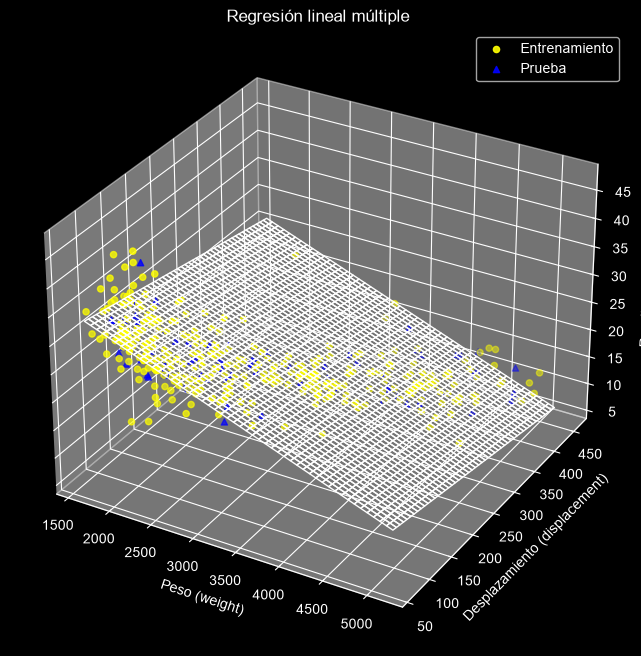

In [35]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

weight_linea = np.linspace(X_data["weight"].min(), X_data["weight"].max(), 50)
displacement_linea = np.linspace(X_data["displacement"].min(), X_data["displacement"].max(), 50)
weight_malla, displacement_malla = np.meshgrid(weight_linea, displacement_linea)

datos_malla = pd.DataFrame({"weight": weight_malla.ravel(), "displacement": displacement_malla.ravel()})
mpg_malla = modelo_multiple.predict(datos_malla).reshape(weight_malla.shape)

fig = plt.figure(figsize=(11, 8))
ax = fig.add_subplot(111, projection="3d")

ax.scatter(X_train["weight"], X_train["displacement"], Y_train, color="yellow", marker="o", alpha=0.9, label="Entrenamiento")
ax.scatter(X_test["weight"], X_test["displacement"], Y_test, color="blue", marker="^", alpha=0.9, label="Prueba")
ax.plot_surface(weight_malla, displacement_malla, mpg_malla, color="white", alpha=0.01)

ax.set_xlabel("Peso (weight)")
ax.set_ylabel("Desplazamiento (displacement)")
ax.set_zlabel("Rendimiento (mpg)")
ax.set_title("Regresión lineal múltiple")
ax.legend()

plt.show()

## Conclusión

La regresión lineal simple permite estudiar de manera clara cómo se relacionan el peso y el rendimiento de combustible. Las métricas y los residuos permiten determinar qué tan adecuada es esa aproximación.

La regresión lineal múltiple incorpora información adicional para explicar la variable objetivo. Para comprobar si el segundo modelo mejora realmente, deben compararse sus métricas sobre el mismo conjunto de prueba.

Una relación estadística útil para predecir no implica necesariamente una relación de causa y efecto.
